In [413]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [519]:
def magnetic_field_wire_finite(x, y, I, w, h, n=25, mu0=4*np.pi*1e-7):
    """
    Magnetic field of a straight wire with finite rectangular cross-section.
    Now includes a progress bar over integration points.
    """

    x = np.asarray(x)
    y = np.asarray(y)

    J = I / (w * h)

    xs = np.linspace(-w/2, w/2, n)
    ys = np.linspace(-h/2, h/2, n)
    dx = w / n
    dy = h / n

    Xp, Yp = np.meshgrid(xs, ys, indexing='xy')

    Bx = np.zeros_like(x, dtype=float)
    By = np.zeros_like(y, dtype=float)

    # flatten integration points for easy progress tracking
    points = list(zip(Xp.ravel(), Yp.ravel()))

    for dxp, dyp in tqdm(points, desc="Integrating current elements", unit="elem"):

        rx = x - dxp
        ry = y - dyp
        r2 = rx**2 + ry**2

        r2 = np.where(r2 == 0, np.inf, r2)

        coef = (mu0 / (2*np.pi)) * J * dx * dy / r2

        Bx += -coef * ry
        By +=  coef * rx

    return Bx, By

def get_g(B0, B1):

    gamma_Er = np.array(np.array([117.3, 117.3, 17.45]) * 1e6)[:, None, None]*np.pi*2 #Khz.rad/T

    B0_norm = B0 / np.linalg.norm(B0)

    # projection of B1 onto B0
    proj = np.sum(B1 * B0_norm, axis=0, keepdims=True) * B0_norm

    B1_perp = B1 - proj

    g0 = np.linalg.norm(B1_perp * gamma_Er, axis=0)/2

    return g0


In [476]:
I = 395*1e-9
x = np.linspace(-5000,5000,10000)*1e-9
y = np.linspace(0,10000,10000)*1e-9

X, Y = np.meshgrid(x, y)
nano_wire_width = 300e-9
nano_wire_height = 50e-9
Bx_wire, By_wire = magnetic_field_wire_finite(X, Y+25e-9, I ,nano_wire_width, nano_wire_height)
Bx_ground, By_ground = magnetic_field_wire_finite(X, Y+1e-6+25e-9, -I ,nano_wire_width, nano_wire_height)
Bx = Bx_wire+Bx_ground
By = By_wire+By_ground


B_norm = np.sqrt(Bx**2+By**2)


Integrating current elements: 100%|██████████| 625/625 [31:59<00:00,  3.07s/elem]


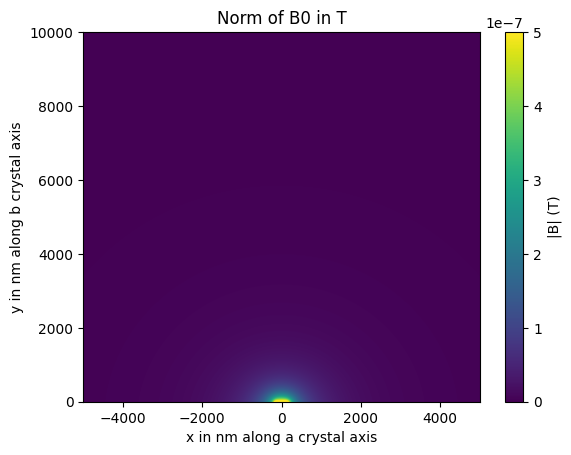

In [477]:
fig, ax = plt.subplots()

im = ax.imshow(
    B_norm,
    origin='lower',
    extent=(x[0]*1e9, x[-1]*1e9, y[0]*1e9, y[-1]*1e9),
    vmin=0,
    vmax=0.5e-6
)

plt.colorbar(im, ax=ax, label='|B| (T)')

ax.set_title('Norm of B0 in T')
ax.set_xlabel('x in nm along a crystal axis')
ax.set_ylabel('y in nm along b crystal axis')
ax.set_aspect('auto')  # or 'equal'


In [520]:
B1 = np.array([Bx,By,np.zeros(Bx.shape)])
alpha = 0*37/180*np.pi
B0 = np.array((np.sin(alpha)*0.166,0,np.cos(alpha)*0.166))

B0 = B0[:, np.newaxis, np.newaxis]
gs = get_g(B0,B1)

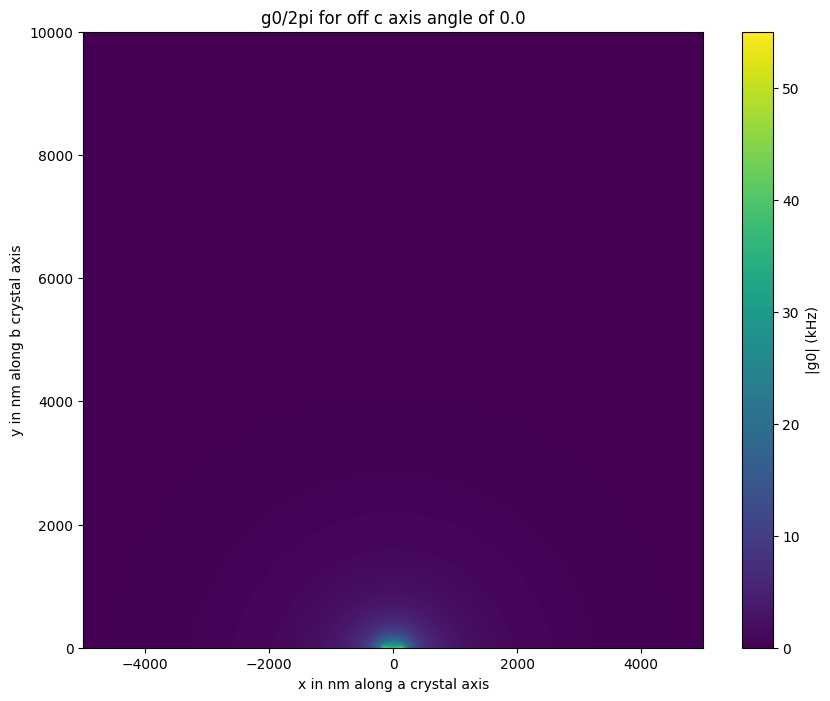

In [532]:
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    gs/(np.pi*2),
    origin='lower',
    extent=(x[0]*1e9, x[-1]*1e9, y[0]*1e9, y[-1]*1e9),
    vmin=0,
    vmax=55,
    interpolation='none'
)
xi = x[len(x)//2]*1e9
yi = y[33]*1e9
plt.colorbar(im, label='|g0| (kHz)')

ax.set_title(f'g0/2pi for off c axis angle of {180/np.pi*alpha:0.1f}')
ax.set_xlabel('x in nm along a crystal axis')
ax.set_ylabel('y in nm along b crystal axis')

ax.set_aspect('auto')  # or 'equal' if you want geometric fidelity
# ax.scatter(xi,yi)


In [463]:
np.where((50e-9-1e-9<=y) & (y<=50e-9+1e-9))


(array([33]),)

In [464]:
gs[33,len(x)//2-1]

np.float64(29.186731240619338)

In [465]:
B_norm[33,len(x)//2-1]

np.float64(4.976424763958967e-07)

In [401]:
xi = x[len(x)//2]*1e9
yi = y[33]*1e9

In [480]:
nano_wire_lenght = 10e-6
crystal_lattice_lenght_a = 4e-10
crystal_lattice_lenght_c = 12e-10
density_1D = nano_wire_lenght/crystal_lattice_lenght_c*4.5/1e9  #nb of erbiums per m^2
# density = 4*1e-9*4*1e-9*12*1e-9
erbiums_per_point = density_1D*(np.abs(x[0]-x[1])/crystal_lattice_lenght_a)*(np.abs(y[0]-y[1])/crystal_lattice_lenght_a)
erbiums_per_point

np.float64(0.00023442188203227094)

In [308]:
erbiums_per_point*70000




np.float64(0.9883243440789442)

(np.float64(0.00019517957026421757), np.float64(46078.42867941867))

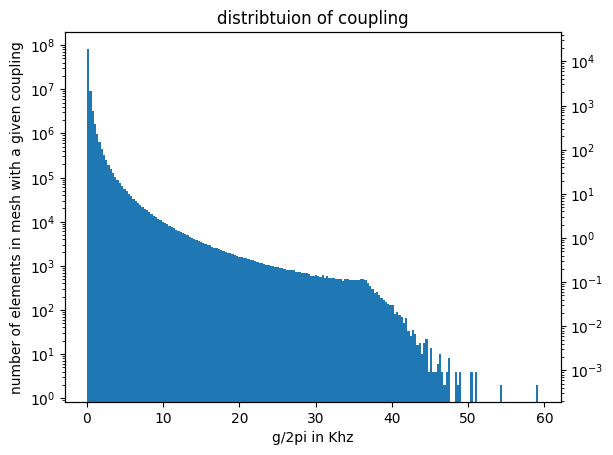

In [521]:
fig,ax = plt.subplots()
counts, bin_edges, patches = ax.hist((gs/(np.pi*2))[gs/(np.pi*2) <= 100], bins=200)
ax2=ax.twinx()

ax.set_title('distribtuion of coupling')
ax.set_xlabel("g/2pi in Khz")
ax.set_ylabel("number of elements in mesh with a given coupling")
ax.set_yscale('log')
ax2.set_yscale('log')

_min,_max = ax.get_ylim()

ax2.set_ylim(_min*erbiums_per_point,_max*erbiums_per_point)

# plt.xlim(0,200)

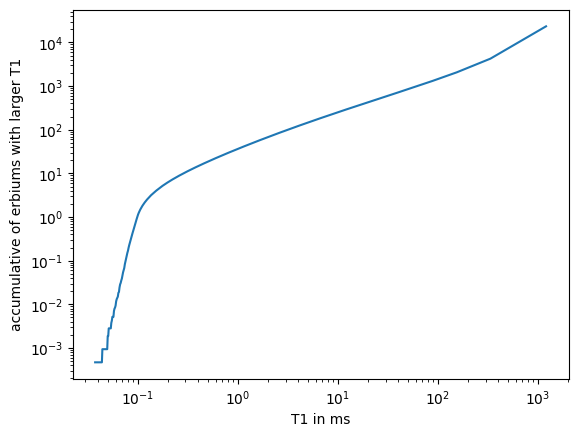

In [530]:
reverse_cumsum = np.cumsum(counts[::-1])[::-1]
decay_rate = 4*(bin_edges[1:]*np.pi*2)**2/(3.3e3*np.pi*2)
plt.plot(1/decay_rate,reverse_cumsum*erbiums_per_point)
plt.yscale('log')
plt.xlabel("T1 in ms")
plt.ylabel("accumulative of erbiums with larger T1" )
plt.xscale('log')
